In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, pointbiserialr
import os

from sklearn.preprocessing import StandardScaler,StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

import missingno as msno
from sklearn.utils import resample

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew
import missingno as msno

## Diabetics Analysis

### Extract the Diabetics patients and equal amount of non Diabetics


HadDiabetes Summary:
                Count  Percentage
has_diabetes                     
0.0           1216560       84.50
1.0            182062       12.65
NaN             41074        2.85


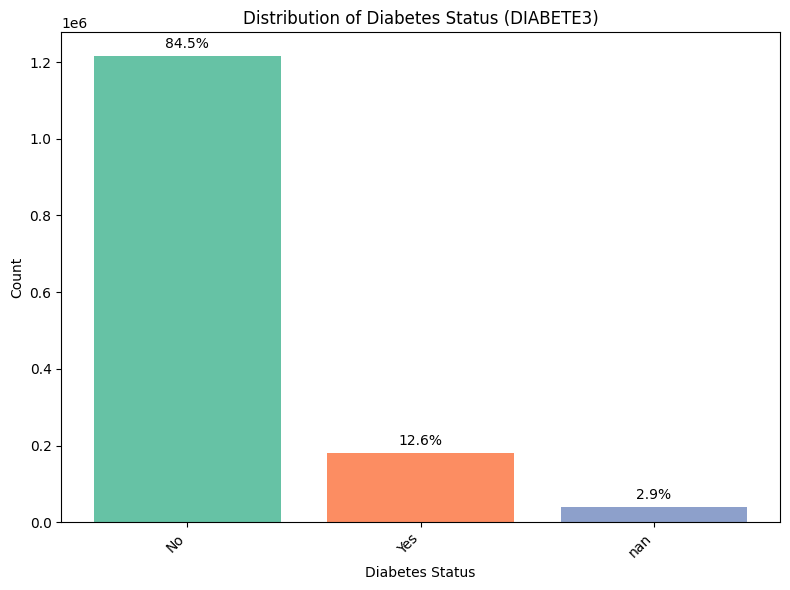

In [2]:
# Create output directory if it doesn't exist

# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_13.csv', low_memory=False)

target = "has_diabetes"

# Check if target exists
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataset. Available columns: {list(df.columns)}")

# Value counts
value_counts = df[target].value_counts(dropna=False).sort_index()
value_percent = df[target].value_counts(normalize=True, dropna=False).sort_index() * 100

# Combine into summary DataFrame
target_summary = pd.DataFrame({
    "Count": value_counts,
    "Percentage": value_percent.round(2)
})

print("\nHadDiabetes Summary:")
print(target_summary)

# --- BAR PLOT (appropriate for categorical data) ---
plt.figure(figsize=(8, 6))

# Define category labels based on BRFSS coding (adjust if your recoding differs)
labels = {
    0.0: 'No',
    1.0: 'Yes',
    float('nan'): 'Missing'
}

# Map index to labels
tick_labels = [labels.get(cat, str(cat)) for cat in value_counts.index]

# Plot
bars = plt.bar(tick_labels, value_counts.values, color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"])

# Add percentage labels on bars
for bar, pct in zip(bars, value_percent.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(value_counts) * 0.01,
             f'{pct:.1f}%', ha='center', va='bottom')

plt.title("Distribution of Diabetes Status (DIABETE3)")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/had_diabetes_bar.png')
plt.show()

In [3]:
counts = df[target].value_counts()
proportions = df[target].value_counts(normalize=True) * 100

print("\nCounts:")
print(counts)
print("\nPercentages:")
print(proportions.round(2))

# Split Majority / Minority

df_majority = df[df[target] == 0.0]
df_minority = df[df[target] == 1.0]

print(f"\nMajority class size (0.0): {len(df_majority)}")
print(f"Minority class size (1.0): {len(df_minority)}")

# Downsample Majority

df_majority_downsampled = resample(
    df_majority,
    replace=False,             # no replacement
    n_samples=len(df_minority),# match minority size
    random_state=42
)

# Combine Balanced Dataset

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\n Balanced dataset created: {df_balanced.shape[0]} rows")

# Check New Distribution

balanced_counts = df_balanced[target].value_counts()
balanced_proportions = df_balanced[target].value_counts(normalize=True) * 100

print("\nBalanced Counts:")
print(balanced_counts)
print("\nBalanced Percentages:")
print(balanced_proportions.round(2))

# Save Balanced Dataset

output_path = '../data/processed/BRFSS_Diabetes_Balanced.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_balanced.to_csv(output_path, index=False)

print(f"\n Balanced dataset saved to: {output_path}")



Counts:
has_diabetes
0.0    1216560
1.0     182062
Name: count, dtype: int64

Percentages:
has_diabetes
0.0    86.98
1.0    13.02
Name: proportion, dtype: float64

Majority class size (0.0): 1216560
Minority class size (1.0): 182062

 Balanced dataset created: 364124 rows

Balanced Counts:
has_diabetes
0.0    182062
1.0    182062
Name: count, dtype: int64

Balanced Percentages:
has_diabetes
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

 Balanced dataset saved to: ../data/processed/BRFSS_Diabetes_Balanced.csv


### Drop Missing than 65%

In [4]:

# Load dataset
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced.csv')

# Step 1: Check missing values
missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 65].index.tolist()

print(f"Features with >65% missing: {high_missing}")

# Step 2: Drop features with >65% missing
df_cleaned = df.drop(columns=high_missing)

# Step 3: Identify target and feature types
target = "has_diabetes"
features = [col for col in df_cleaned.columns if col != target]

# Numerical (exclude binary flags)
numerical_features = df_cleaned[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
binary_features = [col for col in numerical_features 
                   if sorted(df_cleaned[col].dropna().unique()) in [[0,1], [0.0,1.0]]]
numerical_features = [col for col in numerical_features if col not in binary_features]

# Categorical features
categorical_features = df_cleaned[features].select_dtypes(include=['object', 'category']).columns.tolist()

# Step 4: Print summary
print(f"Numerical (non-binary): {len(numerical_features)} -> {numerical_features}")
print(f"Binary: {len(binary_features)} -> {binary_features}")
print(f"Categorical: {len(categorical_features)} -> {categorical_features}")

# Step 5: Save cleaned dataset
cleaned_path = '../data/processed/BRFSS_Diabetes_Balanced_Cleaned.csv'
df_cleaned.to_csv(cleaned_path, index=False)
print(f"\nCleaned dataset saved to: {cleaned_path}")


Features with >65% missing: ['LSTBLDS3', 'takes_aspirin', 'tested_for_diabetes', 'blood_sugar_checks', 'time_since_quit', 'usual_drinks_per_day', 'asthma_now', 'ever_mammogram', 'recent_mammogram', 'ever_pap_test', 'recent_pap_test', 'hiv_test_year', 'is_pregnant']
Numerical (non-binary): 19 -> ['_MISVEGN', 'age_cat', 'chronic_conditions_standard', 'cholesterol_screening_score', 'BMI', 'care_access_score', 'total_exercise_freq', 'total_activity_duration', 'fruit_servings_day', 'juice_servings_day', 'total_fruit_servings', 'total_veg_servings', 'total_fv_servings', 'smoking_status', 'max_drinks_occasion', 'avg_drinks_per_day', 'alcohol_days_year', 'drinks_per_day', 'join_pain_level']
Binary: 48 -> ['had_cvd', 'general_health_cat', 'physical_health_bad', 'poor_health_days', 'has_activity_limitation', 'has_depression', 'has_asthma', 'has_arthritis', 'general_health_risk', 'mental_health_bad', 'has_high_bp', 'has_high_cholesterol', 'has_kidney_disease', 'high_bp_risk', 'had_cholesterol_che

### Remove Metadata like Date time, States

In [5]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced_Cleaned.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 364124
Number of columns: 71

Feature names (columns):
['_MISVEGN', 'age_cat', 'had_cvd', 'general_health_cat', 'physical_health_bad', 'poor_health_days', 'has_activity_limitation', 'has_depression', 'has_asthma', 'has_arthritis', 'general_health_risk', 'mental_health_bad', 'has_high_bp', 'has_high_cholesterol', 'has_kidney_disease', 'chronic_conditions_standard', 'has_diabetes', 'high_bp_risk', 'had_cholesterol_check', 'recent_cholesterol_check', 'no_cholesterol_check_5yr', 'cholesterol_checked_5yr', 'cholesterol_screening_score', 'had_pneumonia_vaccine', 'pneumonia_vaccine_status', 'vaccine_score', 'BMI', 'has_cost_barrier', 'no_cost_barrier', 'care_access_score', 'uses_ecigarettes', 'meets_aerobic_guidelines', 'exercised_past_30d', 'meets_strength_guidelines', 'has_strength_training', 'total_exercise_freq', 'total_activity_duration', 'uses_exercise_equipment', 'fruit_servings_day', 'juice_servings_day', 'total_fruit_servings', 'total_veg_servings', 'total_fv_servings

In [8]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced_Cleaned.csv')

# Define columns to DROP (metadata, weights, admin, non-clinical)
metadata_cols = [
    # # Survey weights & design
    # 'SEQNO', 'MSCODE', '_STATE', '_PSU', '_STRWT', '_STSTR',
    # '_LLCPWT', '_RAWRAKE', '_WT2RAKE', '_CLLCPWT',
    
    # # Date/time
    # 'IDAY', 'IMONTH', 'IDATE', 'IYEAR', 'FMONTH', 'YEAR', 'YEAR.1',
    
    # # Interview/admin metadata
    # 'RCSGENDR', 'CPDEMO1', 'CSTATE', 'CTELENUM', 'CTELNUM1', 'DISPCODE',
    # 'QSTLANG', 'QSTVER', 'LANDLINE', 'CELLFON2', 'PVTRESD2', '_RFSEAT3', '_RFSEAT2',
    
    # # Household composition (not individual health)
    # 'NUMADULT', 'NUMHHOL2', 'NUMMEN', 'NUMWOMEN', 'CADULT',
    
    # # Other non-clinical
    # 'VETERAN3', 'MARITAL', 'RENTHOM1', 'SEATBELT', 'USEEQUIP', 'USENOW3',
    # 'CASTHDX2', 'CVDASPRN', 'IMFVPLAC', 'RCSRLTN2', '_CHLDCNT',
    # 'MAXVO2_', 'FC60_', 

    # # Add any other known non-medical columns here
    # '_VEGRESP', '_FRTRESP'

    '_MISVEGN', 'LSTBLDS3'

]

# Only keep columns that exist in your dataset
cols_to_drop = [col for col in metadata_cols if col in df.columns]
print(f"Found {len(cols_to_drop)} metadata/admin columns to drop.")

# Drop them
df_medical = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape after dropping metadata: {df_medical.shape}")


# Final check
print(f"\n Final dataset shape: {df_medical.shape}")
print(f"Columns remaining: {df_medical.shape[1]}")

# Save
output_path = '../data/processed/BRFSS_Diabetes_MedicalOnly.csv'
df_medical.to_csv(output_path, index=False)
print(f"\n Medical-only dataset saved to: {output_path}")

Found 1 metadata/admin columns to drop.
Shape after dropping metadata: (364124, 70)

 Final dataset shape: (364124, 70)
Columns remaining: 70

 Medical-only dataset saved to: ../data/processed/BRFSS_Diabetes_MedicalOnly.csv


In [9]:
# Show dataset dimensions
print("Number of rows:", df_medical.shape[0])
print("Number of columns:", df_medical.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df_medical.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df_medical.head())

# Show dataset info 
print("\nDataset Info:")
print(df_medical.info())


Number of rows: 364124
Number of columns: 70

Feature names (columns):
['age_cat', 'had_cvd', 'general_health_cat', 'physical_health_bad', 'poor_health_days', 'has_activity_limitation', 'has_depression', 'has_asthma', 'has_arthritis', 'general_health_risk', 'mental_health_bad', 'has_high_bp', 'has_high_cholesterol', 'has_kidney_disease', 'chronic_conditions_standard', 'has_diabetes', 'high_bp_risk', 'had_cholesterol_check', 'recent_cholesterol_check', 'no_cholesterol_check_5yr', 'cholesterol_checked_5yr', 'cholesterol_screening_score', 'had_pneumonia_vaccine', 'pneumonia_vaccine_status', 'vaccine_score', 'BMI', 'has_cost_barrier', 'no_cost_barrier', 'care_access_score', 'uses_ecigarettes', 'meets_aerobic_guidelines', 'exercised_past_30d', 'meets_strength_guidelines', 'has_strength_training', 'total_exercise_freq', 'total_activity_duration', 'uses_exercise_equipment', 'fruit_servings_day', 'juice_servings_day', 'total_fruit_servings', 'total_veg_servings', 'total_fv_servings', 'meets_fr